In [ ]:
# 🧠 Clustering Project: Online Retail Dataset

## 0⃣ Project Initialization

### Sub-task: Load Dataset
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'OnlineRetail.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')
```

---

## 1⃣ Data Understanding

### Sub-task: Check Data Info
```python
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
```

---

## 2⃣ Exploratory Data Analysis (EDA)

### Sub-task: Univariate Analysis
```python
for col in ['Quantity', 'Price']:
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
```

### Sub-task: Violin Plot
```python
sns.violinplot(y='Price', data=df)
plt.title('Violin Plot of Price')
plt.show()
```

### Sub-task: Bivariate and Multivariate Analysis
```python
sns.scatterplot(x='Quantity', y='Price', data=df)
plt.title('Price vs Quantity')
plt.show()
```

### Sub-task: Correlation Matrix
```python
sns.heatmap(df[['Quantity', 'Price']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
```

---

## 3⃣ Data Cleaning

### Sub-task: Handle Missing, Duplicates, Rare Categories
```python
df = df.dropna(subset=['Customer ID'])
df = df.drop_duplicates()
df['Description'] = df['Description'].str.lower().str.strip()

# Rare category grouping
df['Country'] = df['Country'].apply(lambda x: x if df['Country'].value_counts()[x] > 100 else 'Other')
```

### Sub-task: Remove Negative/Zero values
```python
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
```

---

## 4⃣ Feature Engineering

### Sub-task: TotalAmount Feature
```python
df['TotalAmount'] = df['Quantity'] * df['Price']
```

### Sub-task: Date Features
```python
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.weekday
```

### Sub-task: Aggregation Features
```python
agg_df = df.groupby('Customer ID').agg({
    'TotalAmount': ['sum', 'mean'],
    'Quantity': ['sum', 'mean']
}).reset_index()
agg_df.columns = ['Customer ID', 'TotalSpent', 'AvgSpent', 'TotalQty', 'AvgQty']
df = df.merge(agg_df, on='Customer ID', how='left')
```

### Sub-task: Domain Features
```python
df['HighSpender'] = (df['TotalSpent'] > df['TotalSpent'].median()).astype(int)
```

### Sub-task: Interaction Features
```python
df['SpendPerUnit'] = df['TotalAmount'] / df['Quantity']
```

### Sub-task: Polynomial Features
```python
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df[['TotalSpent', 'AvgSpent']].fillna(0))
```

### Sub-task: Binning Features
```python
df['SpendingBin'] = pd.qcut(df['TotalSpent'], q=4, labels=False)
```

---

## 5⃣ Feature Selection for Clustering

### Sub-task: Select Numerical Columns Only
```python
features = ['TotalSpent', 'AvgSpent', 'TotalQty', 'AvgQty']
X = df[features].dropna()
```

### Sub-task: Dimensionality Reduction (PCA)
```python
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
```

### Sub-task: Remove Outliers and Scale
```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

---

## 6⃣ Clustering

### Sub-task: Elbow Method (for K)
```python
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
plt.show()
```

### Sub-task: Silhouette Score
```python
from sklearn.metrics import silhouette_score
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    print(f"K={k}, Silhouette Score={score:.4f}")
```

### Sub-task: Dendrogram (for Agglomerative Clustering)
```python
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()
```

### Sub-task: Apply and Compare All Clustering Algorithms
```python
from sklearn.cluster import DBSCAN, AgglomerativeClustering, OPTICS, Birch
from sklearn.mixture import GaussianMixture

algorithms = {
    'KMeans': KMeans(n_clusters=4, random_state=42),
    'DBSCAN': DBSCAN(eps=1.2, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=4),
    'GMM': GaussianMixture(n_components=4, random_state=42),
    'OPTICS': OPTICS(min_samples=5),
    'Birch': Birch(n_clusters=4)
}

results = []

for name, model in algorithms.items():
    if name == 'GMM':
        model.fit(X_scaled)
        labels = model.predict(X_scaled)
    else:
        model.fit(X_scaled)
        labels = model.labels_

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    results.append((name, sil, ch, db))

results_df = pd.DataFrame(results, columns=['Model', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin'])
print(results_df.sort_values(by='Silhouette', ascending=False))
```

### Sub-task: Apply Best Model (e.g. KMeans)
```python
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(X_scaled)
X_clustered = pd.DataFrame(X_scaled, columns=features)
X_clustered['Cluster'] = kmeans.labels_
```

---

## 7⃣ Evaluation

### Sub-task: Cluster Visualization
```python
sns.pairplot(X_clustered, hue='Cluster', palette='Set2')
plt.suptitle("Cluster Visualization", y=1.02)
plt.show()
```

### Sub-task: Cluster Characteristics
```python
X_clustered['Customer ID'] = df.loc[X_clustered.index, 'Customer ID'].values
print(X_clustered.groupby('Cluster').mean())
```

### Sub-task: Other Evaluation Metrics
```python
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

print("Calinski-Harabasz Index:", calinski_harabasz_score(X_scaled, kmeans.labels_))
print("Davies-Bouldin Score:", davies_bouldin_score(X_scaled, kmeans.labels_))
```

---

## 8⃣ Model Saving

### Sub-task: Save Clustering Model
```python
import joblib
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
```

---

## ✅ Next Steps
- Build dashboard in Power BI using cluster outputs
- Use saved model to assign new customers to segments

In [4]:
#0.project initialization
import pandas as pd 
d=pd.read_csv(r'C:\Users\BHARGAVI\Downloads\advance_ml\online_retail_II.csv')


In [5]:
#1.Data understanding
print(d.shape)
print(d.dtypes)
print(d.info())
print(d.describe())
print(d.nunique())

(1067371, 8)
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1

In [ ]:
#the target variable is not there in unsupervised learning

What is Skewness?
0 = Perfectly symmetrical (normal distribution)
> 0 = Right-skewed (tail on the right)
< 0 = Left-skewed (tail on the left)

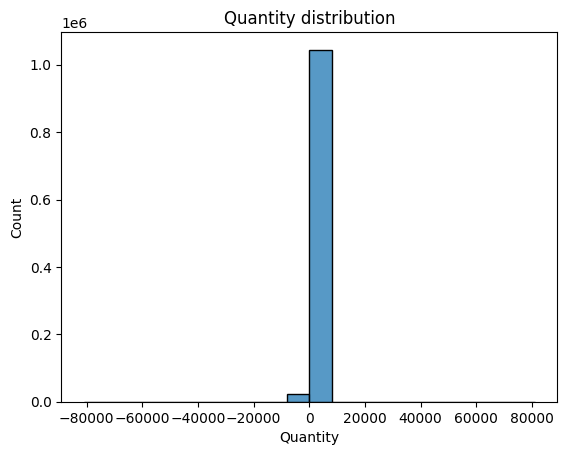

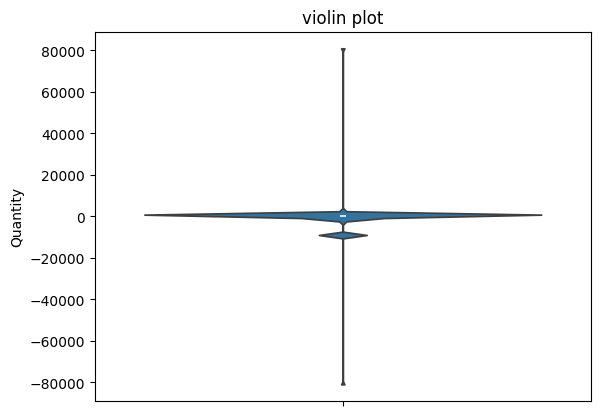

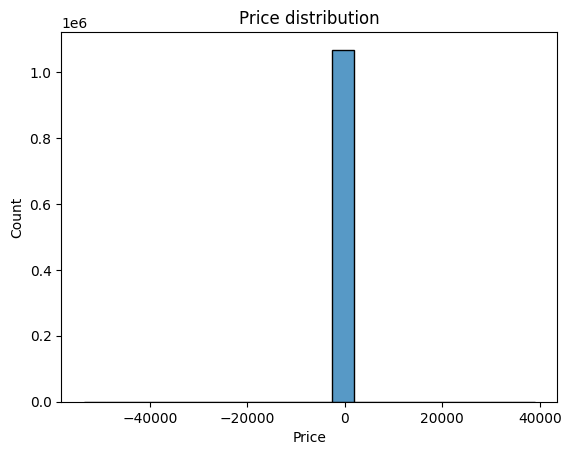

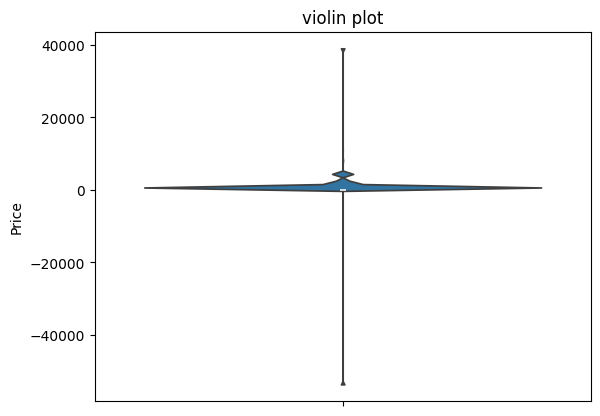

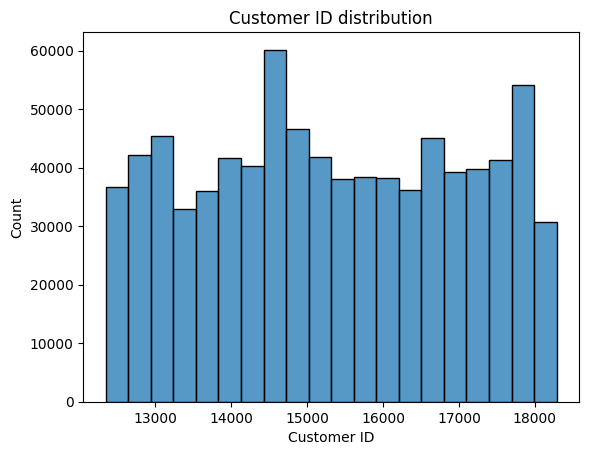

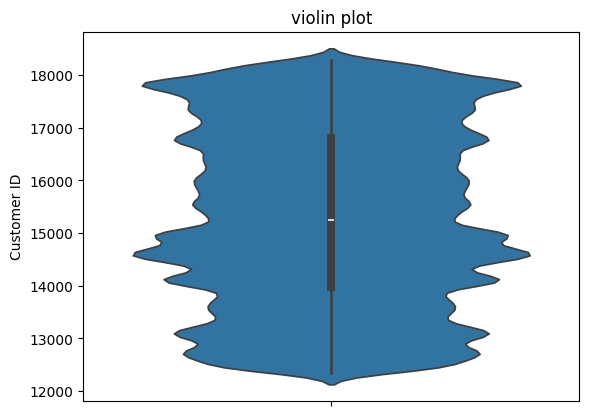

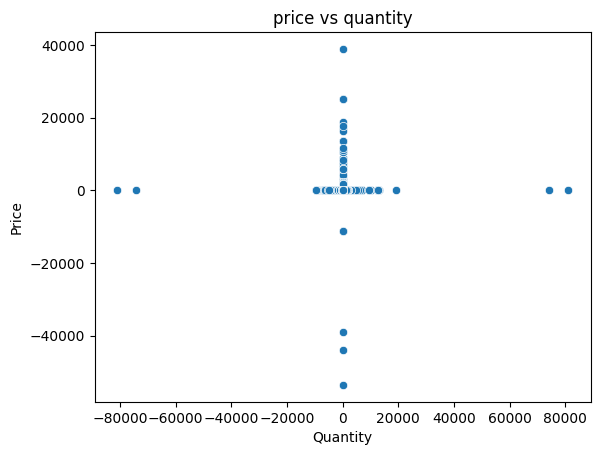

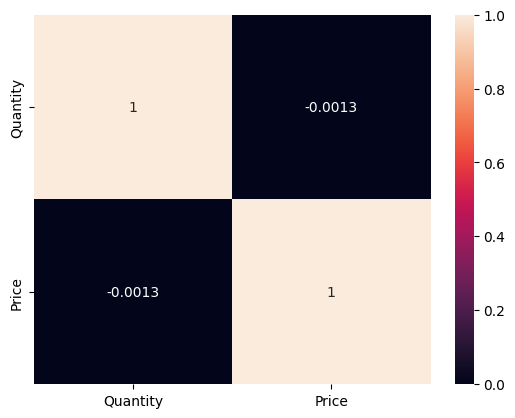

Quantity        3.996145
Customer ID     0.005778
Price         -69.164734
dtype: float64
Zero or negative Quantity: 22950
Zero or negative Price: 6207
Price       1.101056
Quantity    1.018008
dtype: float64


In [6]:
#2.Exploratory Data Analysis
#univariate,kde plot,violinplot
import seaborn as sns 
import matplotlib.pyplot as plt
num=d.select_dtypes(include=['int64','float64']).columns.to_list()
#univariate
for i in num:
    sns.histplot(d[i],bins=20,kde=False)
    plt.title(f"{i} distribution")
    plt.show()

    sns.violinplot(y=d[i])
    plt.title("violin plot")
    plt.show()


#bivariate
sns.scatterplot(x='Quantity',y='Price',data=d)
plt.title('price vs quantity')
plt.show()



### Sub-task: Correlation Matrix
corr=d[['Quantity','Price']].corr()
sns.heatmap(corr,annot=True)
plt.show()

#sub-task: skewness
skewness=d[num].skew()
print(skewness.sort_values(ascending=False))


#count zero or negative values:
print("Zero or negative Quantity:", (d['Quantity'] <= 0).sum())
print("Zero or negative Price:", (d['Price'] <= 0).sum())

#Filter Out Extreme Values
d_filtered= d[(d['Quantity'] > 0) & (d['Quantity'] < 1000) & 
            (d['Price'] > 0) & (d['Price'] < 5000)]

nu=['Quantity','Price']
import numpy as np
nums_transformed=d_filtered.copy()

for i in nu:
    if(d_filtered[i] >=0).all():
        nums_transformed[i] = np.log1p(d_filtered[i])
    else:
        print(f'skipped log transform for {i} ')

#now checking after handling 
skewness=nums_transformed[nu].skew()
print(skewness.sort_values(ascending=False))



Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236103
Country             0
dtype: int64

outliers cleared
outliers cleared
outliers cleared


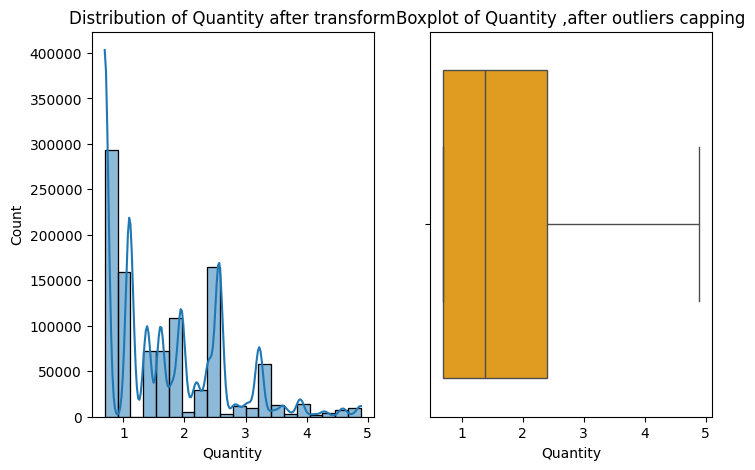

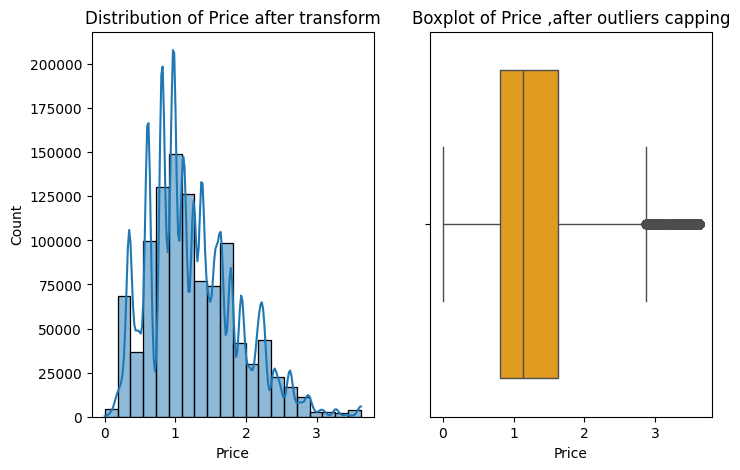

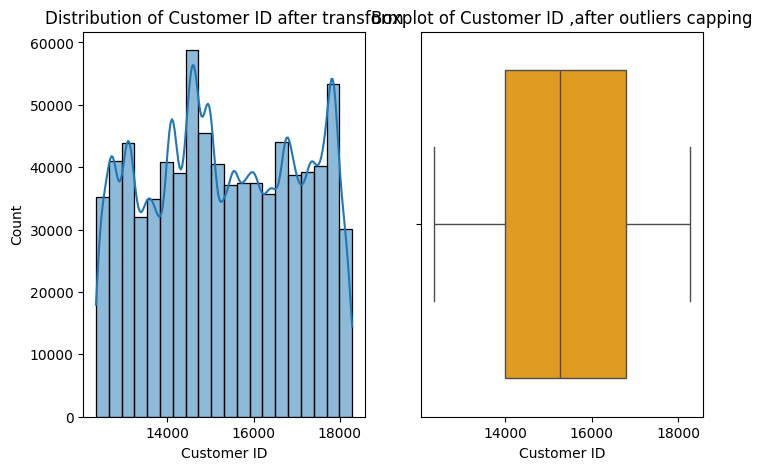

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,2.564949,2009-12-01 07:45:00,2.073172,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,2.564949,2009-12-01 07:45:00,2.047693,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,2.564949,2009-12-01 07:45:00,2.047693,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",3.891820,2009-12-01 07:45:00,1.131402,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,3.218876,2009-12-01 07:45:00,0.810930,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,1.945910,2011-12-09 12:50:00,1.131402,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,1.609438,2011-12-09 12:50:00,1.638997,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,1.609438,2011-12-09 12:50:00,1.638997,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,1.386294,2011-12-09 12:50:00,1.783391,12680.0,France


In [7]:
#3. Data cleaning

print(nums_transformed.columns)
#3.1 missing values
display(nums_transformed.isnull().sum())
num_col=nums_transformed.select_dtypes(include=['int64','float64']).columns.to_list()
#3.2 outliers
def cap_outliers(nums_transformed,i):
    Q1= nums_transformed[i].quantile(0.25)
    Q3= nums_transformed[i].quantile(0.75)
    IQR = Q3*Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound= Q3 + 1.5 * IQR
    nums_transformed[i] = nums_transformed[i].clip(lower_bound,upper_bound)
    print("outliers cleared")

for i in num_col:
    cap_outliers(nums_transformed,i)

#visualization

for v in num_col:
    plt.figure(figsize=(8,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(nums_transformed[v],bins=20,kde=True)
    plt.title(f'Distribution of {v} after transform')

    #Boxplot 
    plt.subplot(1,2,2)
    sns.boxplot(x=nums_transformed[v],color='orange')
    plt.title(f'Boxplot of {v} ,after outliers capping' )


    plt.tight_layout
    plt.show()
    
nums_transformed.drop_duplicates()


In [37]:
#4.Feature Engineering
nums_transformed.columns

#Data features
nums_transformed['InvoiceDate']=pd.to_datetime(nums_transformed['InvoiceDate'])
nums_transformed['Hour']=nums_transformed['InvoiceDate'].dt.hour
nums_transformed['weekday']=nums_transformed['InvoiceDate'].dt.weekday

# Sub-task: Binning
nums_transformed['PriceBin']=pd.qcut(nums_transformed['Price'],q=4,labels=False)

# Sub-task: Text Features
nums_transformed['Description']=nums_transformed['Description'].apply(lambda x: len(str(x)))


# 4⃣ Feature Engineering

### Sub-task: TotalAmount Feature
nums_transformed['TotalAmount'] = nums_transformed['Quantity'] * nums_transformed['Price']

### Sub-task: Aggregation Features
agg_d= nums_transformed.groupby('Customer ID').agg({
    'TotalAmount' : ['sum','mean'],
    'Quantity' : ['sum','mean']
}).reset_index()
agg_d.columns=['Customer ID','TotalSpent','Avgspent','TotalQty','AvgQty']
nums_transformed=nums_transformed.merge(agg_d,on='Customer ID',how='left')

nums_transformed.columns
print(nums_transformed.columns.tolist())





['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Hour', 'weekday', 'PriceBin', 'TotalAmount', 'TotalSpent_x', 'Avgspent_x', 'TotalQty_x', 'AvgQty_x', 'TotalSpent_y', 'Avgspent_y', 'TotalQty_y', 'AvgQty_y', 'TotalSpent', 'Avgspent', 'TotalQty', 'AvgQty']


In [38]:
#5. feature selection
nums_transformed.columns
# Feature Selection for Clustering
# Sub-task: Select Numerical Columns Only

features=['TotalSpent','AvgSpent','TotalQty','AvgQty','Customer ID','Invoice','StockCode','Country','InvoiceDate']
X=nums_transformed.drop(columns=features,errors='ignore')

print(X.dtypes)

# 3. Drop rows with any missing values (NaNs)
X = X.dropna()

# Sub-task: Remove Outliers and Scale
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


# Sub-task: Dimensionality Reduction (PCA)
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)






Description       int64
Quantity        float64
Price           float64
Hour              int32
weekday           int32
PriceBin          int64
TotalAmount     float64
TotalSpent_x    float64
Avgspent_x      float64
TotalQty_x      float64
AvgQty_x        float64
TotalSpent_y    float64
Avgspent_y      float64
TotalQty_y      float64
AvgQty_y        float64
Avgspent        float64
dtype: object


In [36]:
print(X_pca)

[[-3239.17746424   -80.31587818]
 [-3239.17746471   -80.31585851]
 [-3239.17746471   -80.31585851]
 ...
 [-3450.76347559   -47.2892869 ]
 [-3450.76347799   -47.28933962]
 [-3450.76348448   -47.28968804]]


In [45]:
from sklearn.utils import resample

# Sample 10,000 rows if you have a large dataset
X_sampled = resample(X_scaled, n_samples=10000, random_state=42)

wcss = []
silhouette_scores = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)  # Still use full data for WCSS
    wcss.append(kmeans.inertia_)

    if k >= 2:
        # Use the sampled data for silhouette scoring
        labels_sampled = kmeans.predict(X_sampled)
        score = silhouette_score(X_sampled, labels_sampled)
        silhouette_scores.append(score)
        print(f"K={k}, Silhouette Score={score:.4f}")


K=2, Silhouette Score=0.2671
K=3, Silhouette Score=0.2911
K=4, Silhouette Score=0.2570
K=5, Silhouette Score=0.2446
K=6, Silhouette Score=0.2181
K=7, Silhouette Score=0.2316
K=8, Silhouette Score=0.1955
K=9, Silhouette Score=0.1863
K=10, Silhouette Score=0.1934


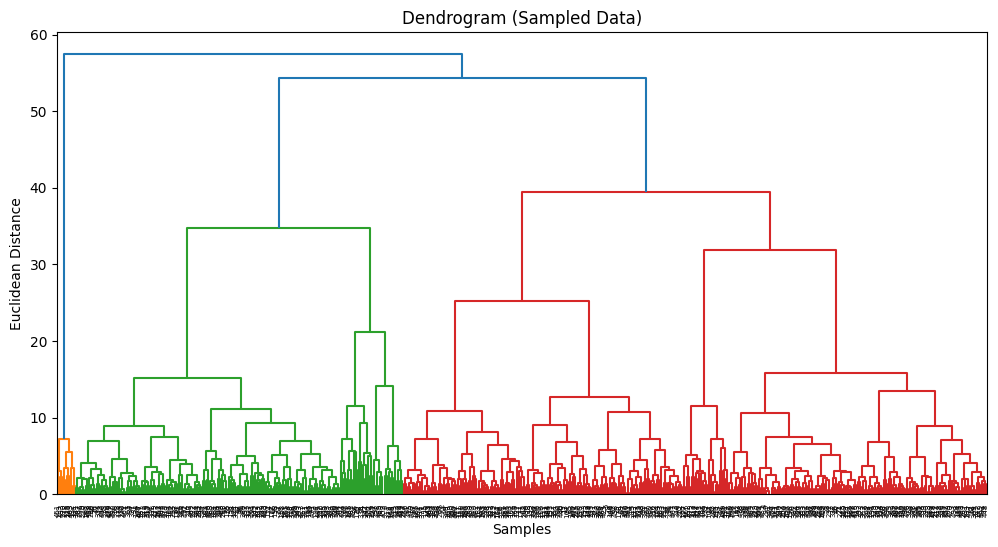

In [47]:


### Sub-task: Dendrogram (for Agglomerative Clustering)

from sklearn.utils import resample
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Sample just 500 rows for visualization
X_sampled = resample(X_scaled, n_samples=500, random_state=42)

plt.figure(figsize=(12, 6))
sch.dendrogram(sch.linkage(X_sampled, method='ward'))
plt.title('Dendrogram (Sampled Data)')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()




In [49]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, OPTICS, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import time

# Use only a sample for faster processing
X_sample = X_scaled[:10000]

# Dictionary of clustering models
algorithms = {
    'KMeans': KMeans(n_clusters=4, random_state=42),
    'DBSCAN': DBSCAN(eps=1.2, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=4),
    'GMM': GaussianMixture(n_components=4, random_state=42),
    'OPTICS': OPTICS(min_samples=5),
    'Birch': Birch(n_clusters=4)
}

results = []

for name, model in algorithms.items():
    print(f"Running {name}...")
    start_time = time.time()
    
    try:
        # Fit and predict
        if name == 'GMM':
            model.fit(X_sample)
            labels = model.predict(X_sample)
        else:
            model.fit(X_sample)
            labels = model.labels_
        
        # Evaluation metrics
        sil = silhouette_score(X_sample, labels)
        ch = calinski_harabasz_score(X_sample, labels)
        db = davies_bouldin_score(X_sample, labels)
        results.append((name, sil, ch, db))
        print(f"{name} completed in {time.time() - start_time:.2f} seconds")
        print(f"Silhouette: {sil:.4f}, Calinski-Harabasz: {ch:.2f}, Davies-Bouldin: {db:.4f}\n")
    
    except Exception as e:
        print(f"{name} failed: {str(e)}\n")

# Results DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin'])
print("\n🔍 Model Comparison (Top by Silhouette Score):")
print(results_df.sort_values(by='Silhouette', ascending=False))


Running KMeans...
KMeans completed in 1.38 seconds
Silhouette: 0.2919, Calinski-Harabasz: 3208.95, Davies-Bouldin: 1.3178

Running DBSCAN...
DBSCAN completed in 1.43 seconds
Silhouette: -0.1776, Calinski-Harabasz: 142.03, Davies-Bouldin: 1.4888

Running Agglomerative...
Agglomerative completed in 3.01 seconds
Silhouette: 0.2965, Calinski-Harabasz: 2802.26, Davies-Bouldin: 1.1897

Running GMM...
GMM completed in 1.62 seconds
Silhouette: 0.1384, Calinski-Harabasz: 1574.13, Davies-Bouldin: 2.1665

Running OPTICS...


c:\Users\BHARGAVI\Downloads\advance_ml\g\lib\site-packages\sklearn\cluster\_optics.py:1086: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


OPTICS completed in 17.03 seconds
Silhouette: 0.0133, Calinski-Harabasz: 17.15, Davies-Bouldin: 1.2501

Running Birch...
Birch completed in 1.71 seconds
Silhouette: 0.2731, Calinski-Harabasz: 2724.57, Davies-Bouldin: 1.3380


🔍 Model Comparison (Top by Silhouette Score):
           Model  Silhouette  Calinski-Harabasz  Davies-Bouldin
2  Agglomerative    0.296485        2802.255996        1.189693
0         KMeans    0.291861        3208.948494        1.317807
5          Birch    0.273131        2724.573838        1.337993
3            GMM    0.138368        1574.131562        2.166482
4         OPTICS    0.013270          17.150177        1.250128
1         DBSCAN   -0.177551         142.031064        1.488750


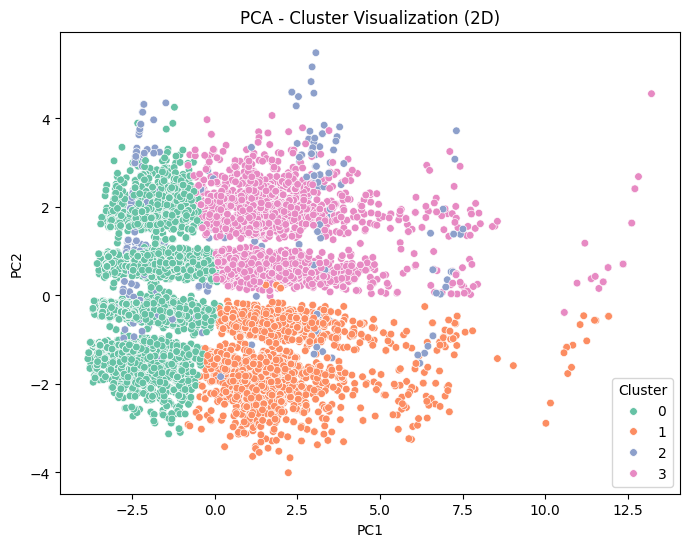


📊 Cluster-wise Mean Statistics:
         feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
Cluster                                                                     
0              0.0      -0.67       0.01       0.12       0.09       0.03   
1              0.0       0.95      -0.69      -0.13       0.11      -0.79   
2              0.0      -0.30       0.22       0.63      -0.14       0.19   
3              0.0       0.01       0.99      -0.11       0.14       1.12   

         feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  \
Cluster                                                                       
0            -0.58      -0.23      -0.84      -0.24       -0.90       -0.23   
1             0.09      -0.20       0.69      -0.20        0.77       -0.20   
2            -0.10       2.88      -0.11       2.94       -0.15        2.88   
3             1.07      -0.18       0.82      -0.20        0.55       -0.18   

         feature_12  feature_

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ✅ Step 1: Use only a sample if not already done
# X_sample = X_scaled[:10000]  # Ensure this is already defined

# ✅ Step 2: Apply KMeans on the sample
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_sample)
labels = kmeans.labels_

# ✅ Step 3: Assign feature names
feature_names = [f'feature_{i}' for i in range(X_sample.shape[1])]
X_clustered = pd.DataFrame(X_sample, columns=feature_names)
X_clustered['Cluster'] = labels

# ✅ Step 4: FAST PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=30)
plt.title("PCA - Cluster Visualization (2D)")
plt.show()

# ✅ Step 5: Cluster-wise statistics
print("\n📊 Cluster-wise Mean Statistics:")
print(X_clustered.groupby('Cluster').mean().round(2))


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# ✅ Refit KMeans (if needed)
# kmeans = KMeans(n_clusters=4, random_state=42)
# kmeans.fit(X_sample)
# labels = kmeans.labels_

# ✅ Prepare clustered DataFrame
feature_names = [f'feature_{i}' for i in range(X_sample.shape[1])]
X_clustered = pd.DataFrame(X_sample, columns=feature_names)
X_clustered['Cluster'] = kmeans.labels_

# 🧠 Optional: Add Customer ID from original DataFrame (df)
# Ensure df is defined and aligned
if 'Customer ID' in df.columns:
    X_clustered['Customer ID'] = df.loc[X_clustered.index, 'Customer ID'].values

# 📉 PCA for fast 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = kmeans.labels_

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=30)
plt.title("📊 PCA Cluster Visualization")
plt.show()

# 📊 Cluster Mean Characteristics
print("\n🔍 Cluster-wise Feature Means:")
print(X_clustered.groupby('Cluster').mean().round(2))

# 🧮 Evaluation Metrics
print("\n📈 Evaluation Metrics (on X_sample):")
print("Calinski-Harabasz Index:", calinski_harabasz_score(X_sample, kmeans.labels_))
print("Davies-Bouldin Score:", davies_bouldin_score(X_sample, kmeans.labels_))


KeyboardInterrupt: 